In [1]:
# imports

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import random_split

from torch.utils.data import TensorDataset, DataLoader
import fitsio
import matplotlib.pyplot as plt

# METAL_LINES_LIST = {
#     "SiII_1190": 1190.4158,
#     "SiII_1193": 1193.2897,
#     "SiIII_1207": 1206.500,
#     "SiII_1260": 1206.500,
#     "CIV_1548": 1548.2049,
#     "CIV_1550": 1550.77845,
#     'MgI(2853)': 2852.96,
# }

### Check transmission file from P1D code

Wavelength shape: (31001,)
Single flux shape: (31001,)


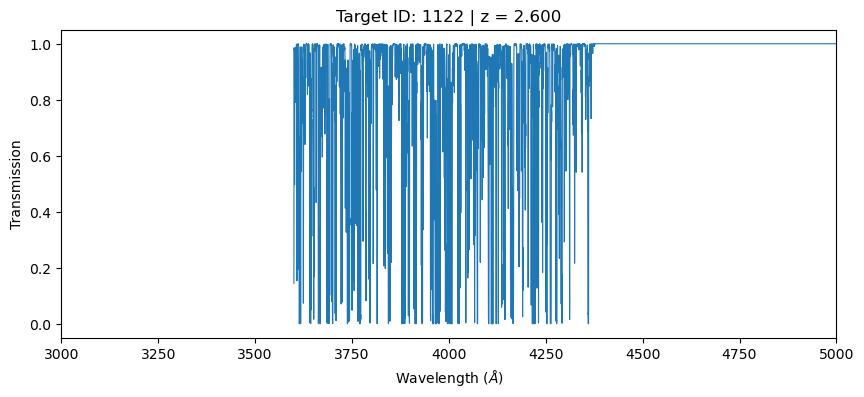

In [2]:
# load transmission file (preprocessed)
p1d_file = '/global/cfs/cdirs/desicollab/users/mherbold/p1d_mocks/DR1/QQ_output_test/transmission-16-1_2.fits'

# Read arrays
meta = fitsio.read(p1d_file, ext="METADATA")
wave = fitsio.read(p1d_file, ext="WAVELENGTH")
fluxes = fitsio.read(p1d_file, ext="TRANSMISSION")

# Pick single spectrum index
i = 100

# Extract and squeeze shape
single_flux = fluxes[i].squeeze()
target_id = meta["MOCKID"][i]
z = meta["Z"][i]

# Check shapes directly
print(f"Wavelength shape: {wave.shape}")        # Output: (31001,)
print(f"Single flux shape: {single_flux.shape}")  # Output: (31001,)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(wave, single_flux, lw=0.8)
plt.xlabel(r"Wavelength ($\AA$)")
plt.ylabel("Transmission")
plt.title(f"Target ID: {target_id} | z = {z:.3f}")
plt.xlim(3000,5000)
plt.show()

### Generate training samples

In [3]:
def rebin_dataset_to_log_lambda(wave_grid: np.ndarray, fluxes: np.ndarray, num_log_pixels: int = None):
    """
    Interpolates a batch of flux spectra from a linear wavelength grid 
    to a strictly uniform log-wavelength grid (constant delta ln(wave)).
    """
    # Define uniform log-wavelength bounds
    log_wave_min = np.log(wave_grid[0])
    log_wave_max = np.log(wave_grid[-1])
    
    if num_log_pixels is None:
        num_log_pixels = len(wave_grid)
        
    log_wave_grid = np.linspace(log_wave_min, log_wave_max, num_log_pixels)
    linear_wave_from_log = np.exp(log_wave_grid)
    
    # Re-interpolate all spectra onto the new uniform log wavelength grid
    N_specs = fluxes.shape[0]
    fluxes_log = np.zeros((N_specs, num_log_pixels), dtype=np.float32)
    
    for idx in range(N_specs):
        fluxes_log[idx] = np.interp(linear_wave_from_log, wave_grid, fluxes[idx])
        
    return log_wave_grid, fluxes_log

In [4]:
# def generate_spectral_dataset(
#     lya_flux_samples: np.ndarray,
#     wave_grid: np.ndarray,
#     A_min: float = 0.01,
#     A_max: float = 1.0, # A = 1, same strength as Lya absorption
#     num_samples: int = 1000,
#     lya_wave: float = 1215.67,
#     metal_wave: float = 1260.42,
#     snr: float = 30.0,
#     seed: int = 123
#     ) -> TensorDataset:
#     """
#     Generates synthetic 2-channel optical depth training pairs from LyA flux spectra
#     with exact cosmological redshift mapping for metal absorption features.

#     Parameters:
#     -----------
#     lya_flux_samples : np.ndarray
#         Array of shape (N_input, N_pixels) containing pure LyA transmission fluxes (0 to 1).
#     wave_grid : np.ndarray
#         1D array of shape (N_pixels,) representing the observed wavelength grid (e.g., in Angstroms).
#     A_min, A_max : float
#         Min and max scale factors for the metal absorption signal.
#         When A_max = 1, this is the same strength as the Lya absorption. 
#         When A_min = 0.01, this is scaled down to 1% of Lya absorption. 
#     num_samples : int
#         Number of output training spectra to generate.
#     lya_wave, metal_wave : float
#         Rest wavelengths for LyA and the target metal line (e.g., Si II 1260.42).
#     snr : float
#         Signal-to-Noise Ratio per pixel for flux noise injection.
#         e.g. SNR = 30, then standard deviation per pix = 1/30 ~ 0.033 
#         For NO noise, pass SNR ~ 1e6, or modify noise = 0
#     seed : int
#         Random seed for reproducibility.

#     Returns:
#     --------
#     TensorDataset yielding (X, y) where:
#         X shape: (2, N_pixels) -> [tau_obs, tau_obs_shifted]
#         y shape: ()           -> log10(A)
#     """
#     np.random.seed(seed)
#     n_input, n_pixels = lya_flux_samples.shape

#     # Ratio > 1.0 when metal_wave > lya_wave (e.g., 1260.42 / 1215.67 = 1.0368)
#     ratio = metal_wave / lya_wave

#     # Pre-compute look-up wavelength grids for redshift transformation
#     # 1. Where to lookup LyA tau to place metal absorption on wave_grid
#     wave_lookup_for_metal = wave_grid / ratio

#     # 2. Where to lookup observed tau to shift metal features back onto LyA features for Channel 2
#     wave_metal_obs = wave_grid * ratio

#     X_data = np.zeros((num_samples, 2, n_pixels), dtype=np.float32)
#     y_data = np.zeros(num_samples, dtype=np.float32)

#     # Convert input flux pool to optical depth: tau = -ln(F)
#     tau_lya_inputs = -np.log(np.clip(lya_flux_samples, 1e-4, 1.0))

#     for i in range(num_samples):
#         # Sample a random LyA spectrum from input pool
#         rand_idx = np.random.randint(0, n_input)
#         tau_lya = tau_lya_inputs[rand_idx]

#         # Draw scale factor A uniformly in log10 space
#         log10_A = np.random.uniform(np.log10(A_min), np.log10(A_max))
#         A = 10.0 ** log10_A

#         # Interpolate LyA optical depth to compute metal forest contribution at each pixel
#         tau_metal_on_grid = np.interp(
#             wave_lookup_for_metal, wave_grid, tau_lya, left=0.0, right=0.0
#         )

#         # Combine components in optical depth space
#         tau_true_total = tau_lya + A * tau_metal_on_grid

#         # Convert to flux space to inject realistic spectrograph noise
#         flux_true = np.exp(-tau_true_total)
#         # noise = np.random.normal(0.0, 1.0 / snr, size=n_pixels)
#         # flux_obs = np.clip(flux_true + noise, 1e-4, 1.5)
        
#         # Handle infinite / disabled noise
#         if snr is None or snr >= 1e5:
#             flux_obs = flux_true
#         else:
#             noise = np.random.normal(0.0, 1.0 / snr, size=n_pixels)
#             flux_obs = np.clip(flux_true + noise, 1e-4, 1.5)
            
#         # Convert noisy flux back to optical depth
#         tau_obs = -np.log(np.clip(flux_obs, 1e-4, 1.0))

#         # Channel 2: Shift tau_obs by wave_metal_obs so that metal absorption features
#         # in Channel 2 align perfectly in pixel index with LyA absorption features in Channel 0
#         tau_obs_shifted = np.interp(
#             wave_metal_obs, wave_grid, tau_obs, left=0.0, right=0.0
#         )

#         # Store in output arrays
#         X_data[i, 0, :] = tau_obs
#         X_data[i, 1, :] = tau_obs_shifted
#         y_data[i] = log10_A

#     # Package as PyTorch TensorDataset
#     X_tensor = torch.from_numpy(X_data)
#     y_tensor = torch.from_numpy(y_data)
#     # return TensorDataset(X_tensor, y_tensor)
#     return TensorDataset(torch.from_numpy(X_data), torch.from_numpy(y_data))


In [30]:
from torch.utils.data import TensorDataset

def generate_multimetal_dataset(
    lya_flux_samples: np.ndarray,
    log_wave_grid: np.ndarray,
    metal_dict: dict,
    lya_wave: float = 1215.67,
    num_samples: int = 1000,
    max_metals_per_spectrum: int = 1,
    snr: float = 30.0,
    tau_min_thresh: float = 0.05
) -> TensorDataset:
    
    n_input, n_pixels = lya_flux_samples.shape
    num_species = len(metal_dict)
    species_keys = list(metal_dict.keys())
    
    d_log_wave = log_wave_grid[1] - log_wave_grid[0]
    
    # Positive pixel shifts for metals redward of LyA (e.g., Mg I 2853 / LyA 1216 > 1)
    pixel_shifts = {}
    for key, w in metal_dict.items():
        delta_log = np.log(w / lya_wave)
        pixel_shifts[key] = int(np.round(delta_log / d_log_wave))

    X_data = np.zeros((num_samples, 1 + num_species, n_pixels), dtype=np.float32)
    Y_mask = np.zeros((num_samples, num_species, n_pixels), dtype=np.float32)
    Y_amp  = np.zeros((num_samples, num_species, n_pixels), dtype=np.float32)

    tau_lya_pool = -np.log(np.clip(lya_flux_samples, 1e-4, 1.0))

    for i in range(num_samples):
        rand_idx = np.random.randint(0, n_input)
        tau_lya = tau_lya_pool[rand_idx]
        tau_total = np.copy(tau_lya)
        
        n_active = np.random.randint(1, max_metals_per_spectrum + 1)
        active_species = np.random.choice(species_keys, size=n_active, replace=False)

        for species in active_species:
            s_idx = species_keys.index(species)
            shift = pixel_shifts[species]
            
            # Amplitude A in linear scale [min, max]
            A = np.random.uniform(0.2, 1.0)
            # A = np.random.uniform(0.2, 0.5)
            log10_A = np.log10(A)
            
            # Metal optical depth placed at pixel k = j + shift
            tau_metal = np.roll(tau_lya, shift)
            if shift > 0:
                tau_metal[:shift] = 0.0
            elif shift < 0:
                tau_metal[shift:] = 0.0
                
            tau_metal_effective = A * tau_metal
            tau_total += tau_metal_effective
            
            # Ground truth targets indexed at the metal line location k
            metal_active_mask = (tau_metal_effective >= tau_min_thresh)
            Y_mask[i, s_idx, :] = metal_active_mask.astype(np.float32)
            Y_amp[i, s_idx, :]  = log10_A

        # Flux conversion & noise injection
        flux_true = np.exp(-tau_total)
        if snr is None or snr >= 1e5:
            flux_obs = flux_true
        else:
            noise = np.random.normal(0.0, 1.0 / snr, size=n_pixels)
            flux_obs = np.clip(flux_true + noise, 1e-4, 1.5)
            
        tau_obs = -np.log(np.clip(flux_obs, 1e-4, 1.0))

        # Channel 0: Unshifted composite optical depth spectrum
        X_data[i, 0, :] = tau_obs
        
        # Channels 1..M: Shifted BY +shift to bring parent LyA optical depth tau_obs[k - shift]
        # to pixel k alongside the metal absorption feature
        for s_idx, species in enumerate(species_keys):
            shift = pixel_shifts[species]
            X_data[i, 1 + s_idx, :] = np.roll(tau_obs, shift)

    return TensorDataset(
        torch.from_numpy(X_data),
        torch.from_numpy(Y_mask),
        torch.from_numpy(Y_amp)
    )

In [47]:
# 1. Resample wavelength AND fluxes to uniform log space
log_wave, fluxes_log = rebin_dataset_to_log_lambda(wave, fluxes)

# 2. Build multi-metal dataset
dataset = generate_multimetal_dataset(
    lya_flux_samples=fluxes_log,
    log_wave_grid=log_wave,
     # metal_dict: dict, # e.g. {"SiII_1260": 1260.42, "CIV_1548": 1548.20, "CIV_1550": 1550.77},
    metal_dict={'MgI_2853': 2852.96, "CIV_1550": 1550.77845},
    num_samples=1000,
    max_metals_per_spectrum=2,
    snr=None
    )

# 3. Create DataLoader (Yields: X, y_mask, y_amp)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Test shape of single batch
for X_batch, y_mask_batch, y_amp_batch in train_loader:
    print(f"X batch shape:      {X_batch.shape}")      # (32, 2, 31001)
    print(f"Mask batch shape:   {y_mask_batch.shape}") # (32, 1, 31001)
    print(f"Amp batch shape:    {y_amp_batch.shape}")  # (32, 1, 31001)
    break

X batch shape:      torch.Size([32, 3, 31001])
Mask batch shape:   torch.Size([32, 2, 31001])
Amp batch shape:    torch.Size([32, 2, 31001])


In [48]:
# # Grab a single batch from the DataLoader (or indexing dataset directly)
# x_batch, y_batch = next(iter(train_loader))

# # Select a sample index to visualize (0 to batch_size - 1)
# sample_idx = 4

# # Extract the channels: original and scaled/shifted spectra
# # PyTorch tensors need to be converted to NumPy arrays
# spec_orig = x_batch[sample_idx, 0, :].detach().cpu().numpy()
# spec_mod = x_batch[sample_idx, 1, :].detach().cpu().numpy()
# label = y_batch[sample_idx].item()

# # Plot single sample comparison
# plt.figure(figsize=(12, 4))
# plt.plot(spec_orig, label="Original Spectrum", alpha=0.8, lw=1.2)
# plt.plot(
#     spec_mod, label="Scaled / Shifted Spectrum", alpha=0.8, lw=1.2, ls="--"
# )

# plt.xlabel("Pixel Index")
# plt.ylabel("Transmission / Flux")
# plt.title(f"Sample {sample_idx} | Target / Parameter: {label:.3f}")
# plt.legend(loc="upper right")
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

### Setting up the CNN Architecture

In [49]:
# class SpectralMetalCNN(nn.Module):
#     def __init__(self):
#         super().__init__()
#         # 1D Conv backbone to extract multi-scale cross-correlation features
#         self.features = nn.Sequential(
#             nn.Conv1d(in_channels=2, out_channels=32, kernel_size=7, stride=2, padding=3),
#             nn.BatchNorm1d(32),
#             nn.ReLU(),
#             nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
#             nn.BatchNorm1d(64),
#             nn.ReLU(),
#             nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
#             nn.BatchNorm1d(128),
#             nn.ReLU(),
#             nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1),
#             nn.BatchNorm1d(256),
#             nn.ReLU(),
#             nn.AdaptiveAvgPool1d(1)  # Pools variable pixel dimensions to shape (B, 256, 1)
#         )
#         # Regression head predicting log10(A)
#         self.regressor = nn.Sequential(
#             nn.Linear(256, 64),
#             nn.ReLU(),
#             nn.Linear(64, 1)
#         )

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         feat = self.features(x)
#         feat = torch.flatten(feat, 1)
#         out = self.regressor(feat)
#         return out.squeeze(-1)  # Shape: (batch_size,)

In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock1D(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Conv1d(out_ch, out_ch, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU()
        )
    def forward(self, x):
        return self.net(x)

class SpectralUNet1D(nn.Module):
    def __init__(self, in_channels: int, num_species: int):
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock1D(in_channels, 32)
        self.pool1 = nn.MaxPool1d(2)
        self.enc2 = ConvBlock1D(32, 64)
        self.pool2 = nn.MaxPool1d(2)
        self.enc3 = ConvBlock1D(64, 128)
        self.pool3 = nn.MaxPool1d(2)
        
        # Bottleneck
        self.bottleneck = ConvBlock1D(128, 256)
        
        # Decoder
        self.dec3 = ConvBlock1D(256 + 128, 128)
        self.dec2 = ConvBlock1D(128 + 64, 64)
        self.dec1 = ConvBlock1D(64 + 32, 32)
        
        # Output Heads (1D convolutions with 1x1 kernel)
        self.cls_head = nn.Conv1d(32, num_species, kernel_size=1) # Logits
        self.reg_head = nn.Conv1d(32, num_species, kernel_size=1) # Amplitude log10(A)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        
        # Bottleneck
        b = self.bottleneck(self.pool3(e3))
        
        # Decoder with length-matched upsampling
        d3 = F.interpolate(b, size=e3.shape[-1], mode='linear', align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        
        d2 = F.interpolate(d3, size=e2.shape[-1], mode='linear', align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        
        d1 = F.interpolate(d2, size=e1.shape[-1], mode='linear', align_corners=False)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        
        # Heads
        mask_logits = self.cls_head(d1)
        amp_pred = self.reg_head(d1)
        
        return mask_logits, amp_pred

In [51]:
# class MultiMetalLoss(nn.Module):
#     def __init__(self, reg_weight: float = 1.0):
#         super().__init__()
#         self.bce = nn.BCEWithLogitsLoss()
#         self.smooth_l1 = nn.SmoothL1Loss(reduction='sum')
#         self.reg_weight = reg_weight

#     def forward(self, pred_logits, pred_amp, target_mask, target_amp):
#         # 1. Classification Loss across all pixels
#         loss_cls = self.bce(pred_logits, target_mask)
        
#         # 2. Masked Regression Loss (only computed on pixels where metals exist)
#         num_positives = target_mask.sum() + 1e-6
#         masked_amp_diff = (pred_amp - target_amp) * target_mask
#         loss_reg = self.smooth_l1(masked_amp_diff, torch.zeros_like(masked_amp_diff)) / num_positives
        
#         total_loss = loss_cls + self.reg_weight * loss_reg
#         return total_loss, loss_cls, loss_reg

# class WeightedMultiMetalLoss(nn.Module):
#     def __init__(self, pos_weight: float = 8.0, reg_weight: float = 1.0):
#         super().__init__()
#         # pos_weight compensates for the ~9:1 ratio of background vs metal pixels
#         self.register_buffer("pos_weight_tensor", torch.tensor([pos_weight]))
#         self.reg_weight = reg_weight
#         self.smooth_l1 = nn.SmoothL1Loss(reduction='sum')

#     def forward(self, pred_logits, pred_amp, target_mask, target_amp):
#         # 1. Class-weighted BCE Loss
#         bce_loss = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight_tensor.to(pred_logits.device))
#         loss_cls = bce_loss(pred_logits, target_mask)
        
#         # 2. Masked Regression Loss (evaluated only at valid target metal pixels)
#         num_positives = target_mask.sum() + 1e-6
#         masked_amp_diff = (pred_amp - target_amp) * target_mask
#         loss_reg = self.smooth_l1(masked_amp_diff, torch.zeros_like(masked_amp_diff)) / num_positives
        
#         total_loss = loss_cls + self.reg_weight * loss_reg
#         return total_loss, loss_cls, loss_reg

In [52]:
class CalibratedMultiMetalLoss(nn.Module):
    def __init__(self, pos_weight: float = 2.5, reg_weight: float = 1.0):
        super().__init__()
        self.register_buffer("pos_weight_tensor", torch.tensor([pos_weight]))
        self.reg_weight = reg_weight
        self.smooth_l1 = nn.SmoothL1Loss(reduction='sum')

    def forward(self, pred_logits, pred_amp, target_mask, target_amp):
        bce_loss = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight_tensor.to(pred_logits.device))
        loss_cls = bce_loss(pred_logits, target_mask)
        
        num_positives = target_mask.sum() + 1e-6
        masked_amp_diff = (pred_amp - target_amp) * target_mask
        loss_reg = self.smooth_l1(masked_amp_diff, torch.zeros_like(masked_amp_diff)) / num_positives
        
        total_loss = loss_cls + self.reg_weight * loss_reg
        return total_loss, loss_cls, loss_reg

In [53]:
# # 1. Train/Validation Split (80/20)
# train_size = int(0.8 * len(dataset))
# val_size = len(dataset) - train_size
# train_set, val_set = random_split(dataset, [train_size, val_size])

# train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
# val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

# # 2. Hardware configuration, loss, and optimizer
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = SpectralMetalCNN().to(device)
# criterion = nn.SmoothL1Loss()
# # SmoothL1Loss = MSE for small error, L1 for large errors
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)


# # 3. Training Loop
# epochs = 30
# train_losses = []
# val_losses = []
# for epoch in range(epochs):
#     model.train()
#     train_loss = 0.0
#     for X_b, y_b in train_loader:
#         X_b, y_b = X_b.to(device), y_b.to(device)
        
#         optimizer.zero_grad()
#         preds = model(X_b)
#         loss = criterion(preds, y_b)
#         loss.backward()
#         optimizer.step()
        
#         train_loss += loss.item() * X_b.size(0)

#     # Validation phase
#     model.eval()
#     val_loss = 0.0
#     with torch.no_grad():
#         for X_b, y_b in val_loader:
#             X_b, y_b = X_b.to(device), y_b.to(device)
#             preds = model(X_b)
#             val_loss += criterion(preds, y_b).item() * X_b.size(0)

#     train_loss /= len(train_set)
#     val_loss /= len(val_set)
    
#     train_losses.append(train_loss)
#     val_losses.append(val_loss)
    
#     if (epoch + 1) % 5 == 0 or (epoch + 1) == epochs:
#         print(
#             f"Epoch {epoch+1:02d}/{epochs} | "
#             f"Train Loss: {train_loss:.4f} | "
#             f"Val Loss: {val_loss:.4f}"
#         )

In [54]:
from torch.optim.lr_scheduler import CosineAnnealingLR

# 1. Train/Validation Split (80/20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=16, shuffle=True) # Reduced batch size to 16 for memory
val_loader = DataLoader(val_set, batch_size=16, shuffle=False)

# 2. Model, Loss, Optimizer
num_channels = dataset[0][0].shape[0]  # e.g., 2 channels (1 raw + 1 shifted)
num_species = dataset[0][1].shape[0]   # e.g., 1 species

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SpectralUNet1D(in_channels=num_channels, num_species=num_species).to(device)

# Positional weight ~ 8.0 to balance 90% continuum vs 10% line pixels
criterion = CalibratedMultiMetalLoss(pos_weight=2.5, reg_weight=1.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

epochs = 30

scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# 3. Training Loop
train_losses = []
val_losses = []
for epoch in range(epochs):
    model.train()
    train_loss, train_cls, train_reg = 0.0, 0.0, 0.0
    
    for X_b, mask_b, amp_b in train_loader:
        X_b, mask_b, amp_b = X_b.to(device), mask_b.to(device), amp_b.to(device)
        
        optimizer.zero_grad()
        pred_logits, pred_amp = model(X_b)
        
        loss, l_cls, l_reg = criterion(pred_logits, pred_amp, mask_b, amp_b)
        loss.backward()
        
        # Clip gradients to prevent loss spikes/instability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item() * X_b.size(0)
        train_cls += l_cls.item() * X_b.size(0)
        train_reg += l_reg.item() * X_b.size(0)

    # Validation phase
    model.eval()
    val_loss, val_cls, val_reg = 0.0, 0.0, 0.0
    with torch.no_grad():
        for X_b, mask_b, amp_b in val_loader:
            X_b, mask_b, amp_b = X_b.to(device), mask_b.to(device), amp_b.to(device)
            
            pred_logits, pred_amp = model(X_b)
            loss, l_cls, l_reg = criterion(pred_logits, pred_amp, mask_b, amp_b)
            
            val_loss += loss.item() * X_b.size(0)
            val_cls += l_cls.item() * X_b.size(0)
            val_reg += l_reg.item() * X_b.size(0)

    scheduler.step()

    train_loss /= len(train_set)
    val_loss /= len(val_set)
    val_cls /= len(val_set)
    val_reg /= len(val_set)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 5 == 0 or (epoch + 1) == epochs:
        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} (Cls: {val_cls:.4f}, Reg: {val_reg:.4f})"
        )

Epoch 05/30 | Train Loss: 0.2259 | Val Loss: 0.2016 (Cls: 0.1957, Reg: 0.0059)
Epoch 10/30 | Train Loss: 0.1153 | Val Loss: 0.1071 (Cls: 0.1050, Reg: 0.0021)
Epoch 15/30 | Train Loss: 0.0713 | Val Loss: 0.0690 (Cls: 0.0673, Reg: 0.0017)
Epoch 20/30 | Train Loss: 0.0547 | Val Loss: 0.0508 (Cls: 0.0498, Reg: 0.0010)
Epoch 25/30 | Train Loss: 0.0485 | Val Loss: 0.0468 (Cls: 0.0460, Reg: 0.0008)
Epoch 30/30 | Train Loss: 0.0481 | Val Loss: 0.0459 (Cls: 0.0452, Reg: 0.0008)


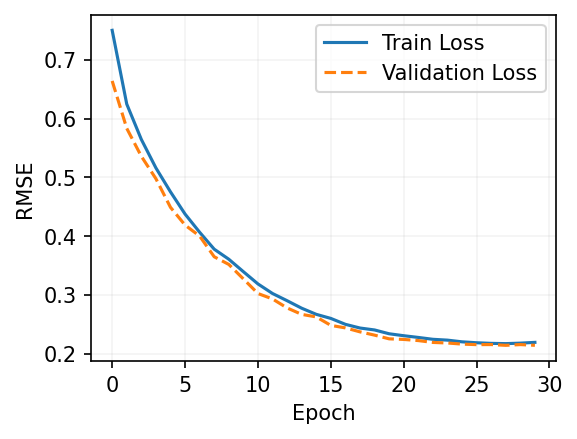

In [55]:
plt.figure(figsize=(4,3), dpi=150)
plt.plot(np.sqrt(train_losses), label='Train Loss')
plt.plot(np.sqrt(val_losses), label='Validation Loss', ls='dashed')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
# plt.ylim(0., 0.3)
plt.grid(alpha=0.15)
plt.legend()
plt.show()

#### Run some diagnostics

In [56]:
# def run_dataset_diagnostics(dataset, wave_grid, num_inspect=3):
#     """
#     Plots individual dataset samples and label distributions for quality control.
#     """
#     # 1. Target Label Distribution Check
#     all_y = [y.item() for _, y in dataset]
    
#     fig, axes = plt.subplots(1, 2, figsize=(14, 4))
#     axes[0].hist(all_y, bins=30, color='navy', alpha=0.7, edgecolor='black')
#     axes[0].set_xlabel(r'Target Label $\log_{10}(A)$')
#     axes[0].set_ylabel('Sample Count')
#     axes[0].set_title('Label Distribution Check')
#     axes[0].grid(True, alpha=0.3)
    
#     # SNR noise floor overlay reference
#     axes[1].scatter(range(len(all_y)), all_y, s=10, c=all_y, cmap='viridis', alpha=0.6)
#     axes[1].set_xlabel('Sample Index')
#     axes[1].set_ylabel(r'$\log_{10}(A)$')
#     axes[1].set_title('Sample Parameter Uniformity')
#     axes[1].grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.show()

#     # 2. Channel Overlay & Alignment Inspection
#     for idx in range(num_inspect):
#         X, y = dataset[idx]
#         tau_obs = X[0].numpy()
#         tau_shifted = X[1].numpy()
#         log10_A = y.item()
#         A_val = 10**log10_A

#         fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
        
#         # Upper Panel: Channel 0 vs Channel 1 on full grid
#         ax1.plot(wave_grid, tau_obs, label=r'Ch 0: $\tau_{obs}$ (Ly$\alpha$ + Metal)', color='black', lw=0.7, alpha=0.8)
#         ax1.plot(wave_grid, tau_shifted, label=r'Ch 1: $\tau_{shifted}$ (Shifted back)', color='crimson', lw=0.7, alpha=0.6)
#         ax1.set_ylabel(r'Optical Depth $\tau$')
#         ax1.set_title(f'Sample #{idx} | $\log_{{10}}(A) = {log10_A:.3f}$ ($A = {A_val:.4f}$)')
#         ax1.legend(loc='upper right')
#         ax1.grid(True, alpha=0.3)
        
#         # Lower Panel: Zoomed-in crop to verify feature alignment
#         # Pick a window in the middle of the wavelength coverage
#         mid_idx = len(wave_grid) // 2
#         zoom_range = slice(mid_idx, mid_idx + 800)
        
#         ax2.plot(wave_grid[zoom_range], tau_obs[zoom_range], color='black', lw=1.0, label=r'Ch 0 ($\tau_{obs}$)')
#         ax2.plot(wave_grid[zoom_range], tau_shifted[zoom_range], color='crimson', lw=1.0, alpha=0.7, label=r'Ch 1 ($\tau_{shifted}$)')
#         ax2.set_xlabel(r'Observed Wavelength ($\mathrm{\AA}$)')
#         ax2.set_ylabel(r'$\tau$ (Zoomed)')
#         ax2.legend(loc='upper right')
#         ax2.grid(True, alpha=0.3)
        
#         plt.tight_layout()
#         plt.show()

# # Run diagnostics on your generated dataset
# run_dataset_diagnostics(dataset, wave)

In [57]:
# def evaluate_spectral_cnn(model, val_loader, device, A_thresh=0.2):
#     model.eval()
#     y_true_list = []
#     y_pred_list = []

#     with torch.no_grad():
#         for X_b, y_b in val_loader:
#             X_b = X_b.to(device)
#             preds = model(X_b)
#             y_true_list.extend(y_b.numpy())
#             y_pred_list.extend(preds.cpu().numpy())

#     y_true = np.array(y_true_list)
#     y_pred = np.array(y_pred_list)
#     residuals = y_pred - y_true

#     # Convert back from log scale to physical linear A space
#     A_true = 10.0 ** y_true
#     A_pred = 10.0 ** y_pred

#     # Calculate metrics
#     mae = np.mean(np.abs(residuals))
#     rmse = np.sqrt(np.mean(residuals**2))

#     # --- 1. Parity and Residual Plots ---
#     fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#     # Parity plot
#     axes[0].scatter(y_true, y_pred, alpha=0.6, color="midnightblue", edgecolors="none", s=25)
#     axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], "r--", lw=2, label="1:1 Line")
#     axes[0].set_xlabel(r"True $\log_{10}(A)$")
#     axes[0].set_ylabel(r"Predicted $\log_{10}(A)$")
#     axes[0].set_title(f"Parity Plot (MAE: {mae:.4f}, RMSE: {rmse:.4f})")
#     axes[0].grid(True, alpha=0.3)
#     axes[0].legend()

#     # Residual plot
#     axes[1].scatter(y_true, residuals, alpha=0.6, color="crimson",
#                     edgecolors="none", s=25)
#     axes[1].axhline(0, color="black", linestyle="--", lw=1.5)
#     axes[1].set_xlabel(r"True $\log_{10}(A)$")
#     axes[1].set_ylabel(
#         r"Residual ($\log_{10}(A_{\mathrm{pred}}) - "
#         r"\log_{10}(A_{\mathrm{true}})$)"
#     )
#     axes[1].set_title("Residual Analysis")
#     axes[1].grid(True, alpha=0.3)

#     plt.tight_layout()
#     plt.show()

#     # --- 2. Purity & Completeness vs Detection Threshold ---
#     log_thresh_val = np.log10(A_thresh)
    
#     # Define boolean arrays for thresholding
#     is_true_metal = y_true >= log_thresh_val
#     is_pred_metal = y_pred >= log_thresh_val

#     tp = np.sum(is_true_metal & is_pred_metal)
#     fp = np.sum(~is_true_metal & is_pred_metal)
#     fn = np.sum(is_true_metal & ~is_pred_metal)
#     tn = np.sum(~is_true_metal & ~is_pred_metal)

#     purity = tp / (tp + fp) if (tp + fp) > 0 else 1.0
#     completeness = tp / (tp + fn) if (tp + fn) > 0 else 1.0

#     print(f"--- Performance @ Threshold A >= {A_thresh} (log10(A) >= {log_thresh_val:.2f}) ---")
#     print(f"True Positives:  {tp:3d} | False Positives: {fp:3d}")
#     print(f"False Negatives: {fn:3d} | True Negatives:  {tn:3d}")
#     print(f"Purity (Precision):     {purity:.4f}")
#     print(f"Completeness (Recall):  {completeness:.4f}")

#     # --- 3. Purity/Completeness Curves across Amplitude Sweep ---
#     threshold_sweep = np.linspace(y_true.min(), y_true.max(), 50)
#     purities = []
#     completenesses = []

#     for th in threshold_sweep:
#         t_pos = np.sum((y_true >= th) & (y_pred >= th))
#         f_pos = np.sum((y_true < th) & (y_pred >= th))
#         f_neg = np.sum((y_true >= th) & (y_pred < th))

#         pur = t_pos / (t_pos + f_pos) if (t_pos + f_pos) > 0 else 1.0
#         comp = t_pos / (t_pos + f_neg) if (t_pos + f_neg) > 0 else 1.0

#         purities.append(pur)
#         completenesses.append(comp)

#     plt.figure(figsize=(8, 4))
#     plt.plot(10**threshold_sweep, purities, label="Purity (Precision)", color="teal", lw=2)
#     plt.plot(10**threshold_sweep, completenesses, label="Completeness (Recall)", color="darkorange", lw=2)
#     plt.xlabel(r"Amplitude Threshold $A$")
#     plt.ylabel("Fraction")
#     plt.title("Purity & Completeness vs Amplitude Threshold")
#     plt.grid(True, alpha=0.3)
#     plt.legend()
#     plt.show()

# # Run evaluation on validation set
# evaluate_spectral_cnn(model, val_loader, device, A_thresh=0.2)

In [58]:
def evaluate_multimetal_unet(
    model, 
    val_loader, 
    device, 
    metal_names: list = None, 
    prob_thresh: float = 0.5,
    a_min: float = 0.2,
    a_max: float = 1.0,
    # log_a_min: float = -2.0,
    # log_a_max: float = 0.0
):
    """
    Evaluates a pixel-level Multi-Metal 1D U-Net model.
    Generates Parity, Residual, and Purity/Completeness plots per metal species.
    """
    model.eval()

    log_a_min = np.log10(a_min)
    log_a_max = np.log10(a_max)
    
    all_mask_true = []
    all_amp_true  = []
    all_prob_pred = []
    all_amp_pred  = []

    with torch.no_grad():
        for X_b, mask_b, amp_b in val_loader:
            X_b = X_b.to(device)
            logits_pred, amp_pred = model(X_b)
            probs_pred = torch.sigmoid(logits_pred)

            all_mask_true.append(mask_b.numpy())
            all_amp_true.append(amp_b.numpy())
            all_prob_pred.append(probs_pred.cpu().numpy())
            all_amp_pred.append(amp_pred.cpu().numpy())

    # Concatenate all validation batches -> shape: (N_samples, M_species, N_pixels)
    mask_true = np.concatenate(all_mask_true, axis=0)
    amp_true  = np.concatenate(all_amp_true, axis=0)
    prob_pred = np.concatenate(all_prob_pred, axis=0)
    amp_pred  = np.concatenate(all_amp_pred, axis=0)

    num_species = mask_true.shape[1]
    if metal_names is None:
        metal_names = [f"Species_{i+1}" for i in range(num_species)]

    # Iterate over each metal line species
    for m_idx, species_name in enumerate(metal_names):
        m_mask_true = mask_true[:, m_idx, :].flatten()
        m_amp_true  = amp_true[:, m_idx, :].flatten()
        m_prob_pred = prob_pred[:, m_idx, :].flatten()
        m_amp_pred  = amp_pred[:, m_idx, :].flatten()

        # Binary truth and predictions at current detection threshold
        is_true = m_mask_true > 0.5
        is_pred = m_prob_pred >= prob_thresh

        # --- 1. Confusion Matrix Metrics ---
        tp = np.sum(is_true & is_pred)
        fp = np.sum(~is_true & is_pred)
        fn = np.sum(is_true & ~is_pred)
        tn = np.sum(~is_true & ~is_pred)

        purity = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        completeness = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        print(f"\n" + "="*60)
        print(f" Performance Metrics: {species_name} (Prob Threshold >= {prob_thresh})")
        print(f"="*60)
        print(f" True Positives (Pixels):  {tp:8d} | False Positives: {fp:8d}")
        print(f" False Negatives (Pixels): {fn:8d} | True Negatives:  {tn:8d}")
        print(f" Purity (Precision):       {purity:.4f}")
        print(f" Completeness (Recall):    {completeness:.4f}")

        # --- 2. Amplitude Recovery Metrics (Evaluated at Ground Truth Metal Pixels) ---
        gt_true_amps = m_amp_true[is_true]
        gt_pred_amps = m_amp_pred[is_true]

        if len(gt_true_amps) > 0:
            residuals = gt_pred_amps - gt_true_amps
            mae = np.mean(np.abs(residuals))
            rmse = np.sqrt(np.mean(residuals**2))
            print(f" Amplitude MAE  [log10(A)]: {mae:.4f}")
            print(f" Amplitude RMSE [log10(A)]: {rmse:.4f}")

            # --- 3. Diagnostics Plotting (1x3 Panel per metal) ---
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))

            # Panel 1: Parity Plot
            axes[0].scatter(gt_true_amps, gt_pred_amps, alpha=0.2, color="midnightblue", s=8, edgecolors="none")
            axes[0].plot([log_a_min, log_a_max], [log_a_min, log_a_max], "r--", lw=2, label="1:1 Line")
            axes[0].set_xlabel(r"True $\log_{10}(A)$")
            axes[0].set_ylabel(r"Predicted $\log_{10}(A)$")
            axes[0].set_title(f"{species_name} - Amplitude Parity\n(MAE: {mae:.4f}, RMSE: {rmse:.4f})")
            axes[0].grid(True, alpha=0.3)
            axes[0].legend()

            # Panel 2: Residual Plot
            axes[1].scatter(gt_true_amps, residuals, alpha=0.2, color="crimson", s=8, edgecolors="none")
            axes[1].axhline(0, color="black", linestyle="--", lw=1.5)
            axes[1].set_xlabel(r"True $\log_{10}(A)$")
            axes[1].set_ylabel(r"Residual ($\log_{10}(A_{\mathrm{pred}}) - \log_{10}(A_{\mathrm{true}})$)")
            axes[1].set_title(f"{species_name} - Residual Analysis")
            axes[1].grid(True, alpha=0.3)

            # Panel 3: Purity & Completeness Curves (Sweep over Probability Threshold)
            prob_sweep = np.linspace(0.01, 0.99, 50)
            purities, completenesses = [], []
            for p_th in prob_sweep:
                pred_pos = m_prob_pred >= p_th
                tp_i = np.sum(is_true & pred_pos)
                fp_i = np.sum(~is_true & pred_pos)
                fn_i = np.sum(is_true & ~pred_pos)
                
                pur_i = tp_i / (tp_i + fp_i) if (tp_i + fp_i) > 0 else 1.0
                comp_i = tp_i / (tp_i + fn_i) if (tp_i + fn_i) > 0 else 1.0
                purities.append(pur_i)
                completenesses.append(comp_i)

            axes[2].plot(prob_sweep, purities, label="Purity (Precision)", color="teal", lw=2)
            axes[2].plot(prob_sweep, completenesses, label="Completeness (Recall)", color="darkorange", lw=2)
            axes[2].axvline(prob_thresh, color="gray", linestyle=":", label=f"Current Thresh ({prob_thresh})")
            axes[2].set_xlabel("Detection Probability Threshold")
            axes[2].set_ylabel("Fraction")
            axes[2].set_title(f"{species_name} - Purity & Completeness")
            axes[2].grid(True, alpha=0.3)
            axes[2].legend()

            plt.tight_layout()
            plt.show()

In [59]:
def plot_sample_spectrum_prediction(
    model, 
    val_set, 
    log_wave_grid: np.ndarray, 
    device, 
    sample_idx: int = 0, 
    metal_names: list = None
):
    """
    Plots a single validation spectrum showing observed optical depth alongside 
    true vs predicted metal absorption masks and amplitudes.
    """
    model.eval()
    X_sample, mask_true, amp_true = val_set[sample_idx]
    
    # Run inference
    with torch.no_grad():
        X_in = X_sample.unsqueeze(0).to(device)
        logits_pred, amp_pred = model(X_in)
        probs_pred = torch.sigmoid(logits_pred).squeeze(0).cpu().numpy()
        amp_pred = amp_pred.squeeze(0).cpu().numpy()

    mask_true = mask_true.numpy()
    amp_true = amp_true.numpy()
    tau_obs = X_sample[0].numpy()
    wave_linear = np.exp(log_wave_grid)
    
    num_species = mask_true.shape[0]
    if metal_names is None:
        metal_names = [f"Species_{i+1}" for i in range(num_species)]

    fig, axes = plt.subplots(1 + num_species, 1, figsize=(14, 3 * (1 + num_species)), sharex=True)
    if num_species == 1:
        axes = [axes[0], axes[1]]

    # Panel 0: Observed Composite Spectrum
    axes[0].plot(wave_linear, np.exp(-tau_obs), color="black", lw=0.7, label=r"Observed Transmission $e^{-\tau}$")
    axes[0].set_ylabel("Flux")
    axes[0].set_title(f"Validation Sample #{sample_idx} Inspection")
    axes[0].legend(loc="upper right")
    axes[0].grid(True, alpha=0.3)

    # Species Panels
    for m in range(num_species):
        ax = axes[m + 1]
        ax.plot(wave_linear, probs_pred[m], color="crimson", label=f"{metal_names[m]} Pred Probability")
        ax.fill_between(wave_linear, 0, mask_true[m], color="gray", alpha=0.3, label="True Line Mask")
        
        ax.set_ylabel("Probability / Mask")
        ax.set_ylim(-0.05, 1.05)
        ax.legend(loc="upper right")
        ax.grid(True, alpha=0.3)
        
    axes[-1].set_xlabel(r"Observed Wavelength ($\AA$)")
    plt.tight_layout()
    plt.show()


 Performance Metrics: MgI_2853 (Prob Threshold >= 0.5)
 True Positives (Pixels):    284374 | False Positives:    10359
 False Negatives (Pixels):     4073 | True Negatives:   5901394
 Purity (Precision):       0.9649
 Completeness (Recall):    0.9859
 Amplitude MAE  [log10(A)]: 0.0225
 Amplitude RMSE [log10(A)]: 0.0323


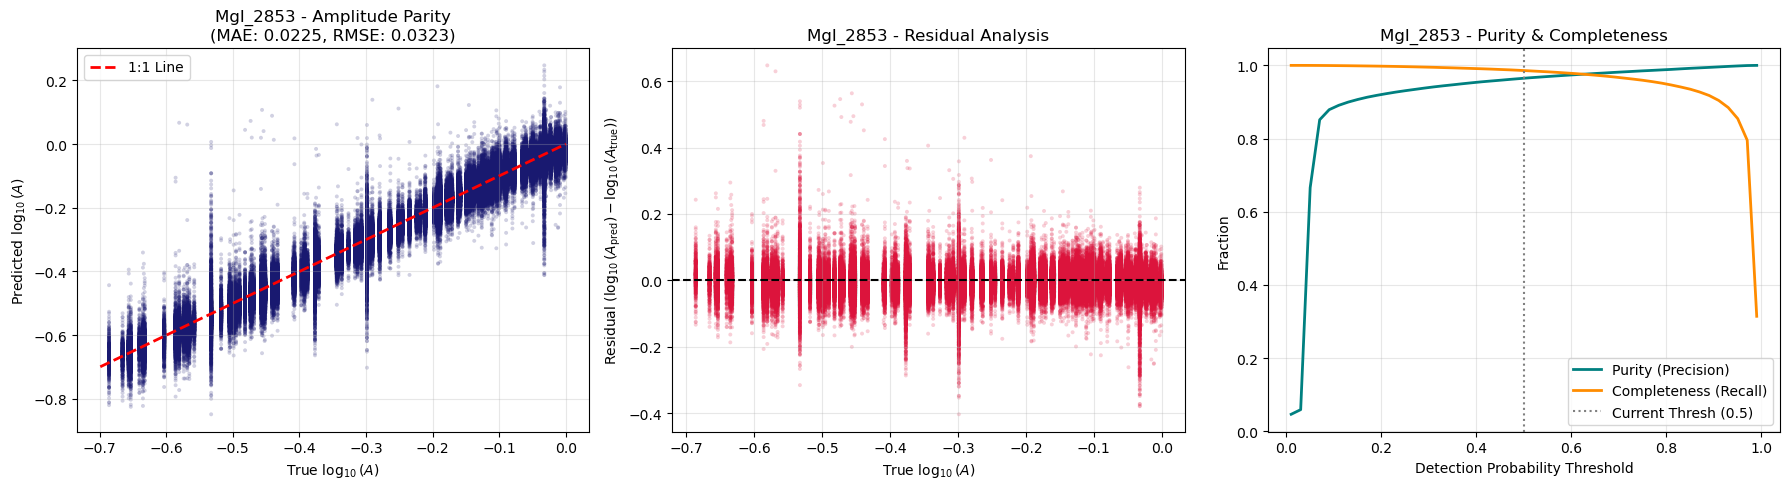


 Performance Metrics: CIV_1550 (Prob Threshold >= 0.5)
 True Positives (Pixels):    428003 | False Positives:    23708
 False Negatives (Pixels):     7403 | True Negatives:   5741086
 Purity (Precision):       0.9475
 Completeness (Recall):    0.9830
 Amplitude MAE  [log10(A)]: 0.0306
 Amplitude RMSE [log10(A)]: 0.0446


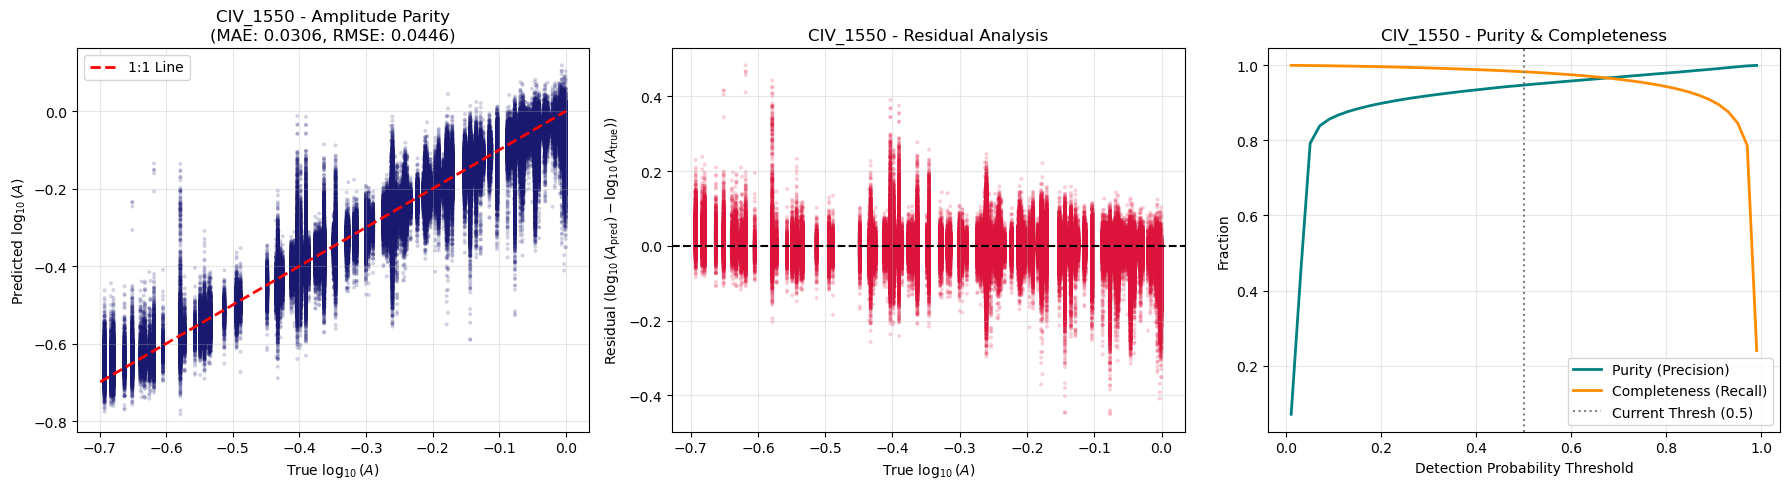

In [63]:
# 1. Run global statistical evaluation & plots across all validation samples
evaluate_multimetal_unet(
    model=model,
    val_loader=val_loader,
    device=device,
    metal_names=['MgI_2853', "CIV_1550"], # Add additional metal names matching your dict order
    # metal_names = ['SiII_1260'],
    prob_thresh=0.5,
    a_max = 1.0,
    a_min = 0.2,
)

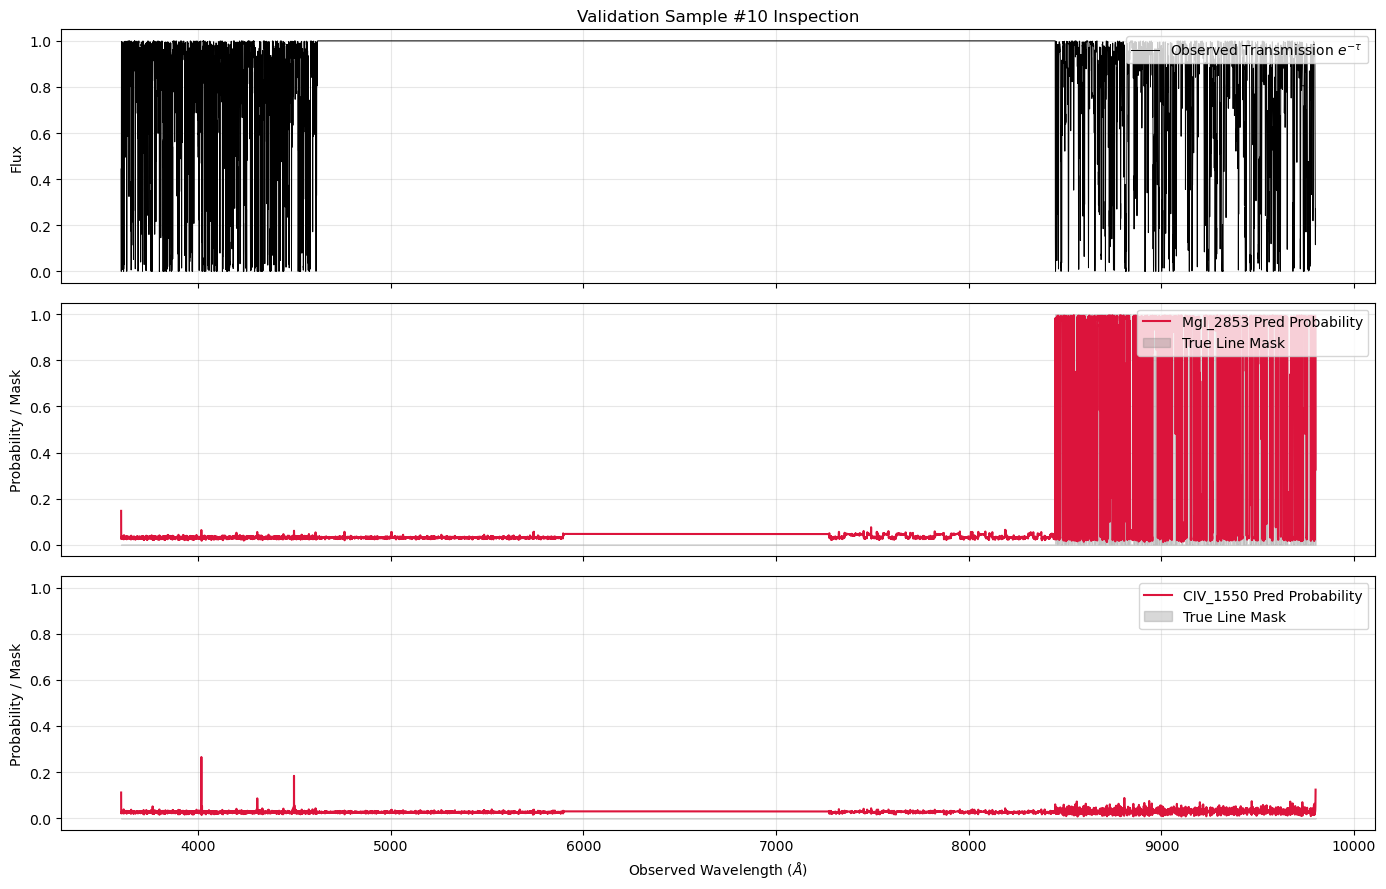

In [62]:
# 2. Inspect a specific 1D spectrum visually
plot_sample_spectrum_prediction(
    model=model,
    val_set=val_set,
    log_wave_grid=log_wave,
    device=device,
    sample_idx=10,
    metal_names=['MgI_2853', 'CIV_1550'],
    # metal_names = ['SiII_1260']
)